# Purrfect Platform Architecture Diagram

This notebook creates a clear and visual representation of the Purrfect platform's architecture, showing the relationships between different components including Frontend, API Layer, Orchestrator, Core Agents, Advanced Agents, Data Stores, and External Services.

## 1. Import Required Libraries

In [1]:
# Install required packages if not already installed
try:
    import networkx as nx
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle
    import matplotlib.colors as mcolors
except ImportError:
    import sys
    !{sys.executable} -m pip install networkx matplotlib
    import networkx as nx
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle
    import matplotlib.colors as mcolors

# For displaying the output
from IPython.display import display
import io
import PIL.Image

## 2. Define Architecture Components

In [2]:
# Initialize a NetworkX directed graph
G = nx.DiGraph()

# Define color scheme for different component groups
colors = {
    'frontend': '#E0F7FA',      # Light cyan
    'api': '#E8F5E9',           # Light green
    'orchestrator': '#FFF9C4',  # Light yellow
    'core_agents': '#F3E5F5',   # Light purple
    'advanced_agents': '#FFE0B2', # Light orange
    'data_stores': '#E1F5FE',   # Light blue
    'external_services': '#FFEBEE' # Light red
}

# Node positions by group
pos = {}

## 3. Create the Architecture Diagram

In [3]:
# Define all nodes with their labels and categories

# Frontend nodes
frontend_nodes = [
    ('D1', 'Dashboard'),
    ('D2', 'Features & Tools'),
    ('D3', 'Exam Q&A Stepper'),
    ('D4', 'Progress & Calendar'),
    ('D5', 'Notes Editor'),
    ('D6', 'Planning Forms'),
    ('D7', 'Settings & Memory Control')
]

# API Layer nodes
api_nodes = [
    ('A1', 'Auth & Session Controller'),
    ('A2', 'ExamAssist Controller'),
    ('A3', 'Agent Runner Controller'),
    ('A4', 'Memory Controller')
]

# Orchestrator nodes
orchestrator_nodes = [
    ('O1', 'Clawdia Coordinator'),
    ('O2', 'Dynamic Intent Router'),
    ('O3', 'Multi-Agent Pipeline')
]

# Core Agents nodes
core_agents_nodes = [
    ('AG1', 'AnswerEvaluatorAgent'),
    ('AG2', 'TeachingAgent'),
    ('AG3', 'PlannerAgent'),
    ('AG4', 'FlashcardAgent'),
    ('AG5', 'CollabAgent'),
    ('AG6', 'GameAgent'),
    ('AG7', 'ExamCoachAgent')
]

# Advanced Agents nodes
advanced_agents_nodes = [
    ('AG8', 'MetaLearnerAgent'),
    ('AG9', 'CurriculumGeneratorAgent'),
    ('AG10', 'SRSAgent'),
    ('AG11', 'MultimodalIngestAgent'),
    ('AG12', 'EmotionAgent'),
    ('AG13', 'SocialMatchAgent'),
    ('AG14', 'ExplainabilityAgent'),
    ('AG15', 'ArchivistAgent'),
    ('AG16', 'ContentCuratorAgent'),
    ('AG17', 'PluginManagerAgent')
]

# Data Stores nodes
data_store_nodes = [
    ('DB1', 'PostgreSQL'),
    ('DB2', 'Qdrant')
]

# External Services nodes
external_services_nodes = [
    ('S1', 'LLM API'),
    ('S2', 'Embeddings API'),
    ('S3', 'OCR Service'),
    ('S4', 'TTS/STT Service'),
    ('S5', 'Emotion Detection API'),
    ('S6', 'OER / Syllabus APIs'),
    ('S7', 'Peer Matching Service')
]

# Add all nodes to the graph with their categories
node_categories = {}

for node, label in frontend_nodes:
    G.add_node(node, label=label)
    node_categories[node] = 'frontend'

for node, label in api_nodes:
    G.add_node(node, label=label)
    node_categories[node] = 'api'

for node, label in orchestrator_nodes:
    G.add_node(node, label=label)
    node_categories[node] = 'orchestrator'

for node, label in core_agents_nodes:
    G.add_node(node, label=label)
    node_categories[node] = 'core_agents'

for node, label in advanced_agents_nodes:
    G.add_node(node, label=label)
    node_categories[node] = 'advanced_agents'

for node, label in data_store_nodes:
    G.add_node(node, label=label)
    node_categories[node] = 'data_stores'

for node, label in external_services_nodes:
    G.add_node(node, label=label)
    node_categories[node] = 'external_services'

# Define positions for nodes based on their group
# This creates a layered architecture visualization

# Calculate position Y-coordinates for each group
group_y = {
    'frontend': 7,
    'api': 6,
    'orchestrator': 5,
    'core_agents': 4,
    'advanced_agents': 3,
    'data_stores': 1,
    'external_services': 0
}

# Helper function to distribute nodes horizontally within their group
def distribute_nodes_horizontally(nodes, y_pos, start_x=0, spacing=1):
    positions = {}
    total_width = len(nodes) * spacing
    start_x = -total_width / 2 + spacing / 2
    
    for i, node in enumerate(nodes):
        positions[node] = (start_x + i * spacing, y_pos)
    
    return positions

# Create positions for all nodes
pos.update(distribute_nodes_horizontally([n for n, _ in frontend_nodes], group_y['frontend']))
pos.update(distribute_nodes_horizontally([n for n, _ in api_nodes], group_y['api']))
pos.update(distribute_nodes_horizontally([n for n, _ in orchestrator_nodes], group_y['orchestrator']))
pos.update(distribute_nodes_horizontally([n for n, _ in core_agents_nodes], group_y['core_agents']))
pos.update(distribute_nodes_horizontally([n for n, _ in advanced_agents_nodes], group_y['advanced_agents']))
pos.update(distribute_nodes_horizontally([n for n, _ in data_store_nodes], group_y['data_stores']))
pos.update(distribute_nodes_horizontally([n for n, _ in external_services_nodes], group_y['external_services']))

## 4. Add Component Relationships

In [4]:
# Define edge categories for different types of connections
edge_styles = {
    'ui': {'style': 'dashed', 'width': 1.0, 'alpha': 0.7},
    'data': {'style': 'dotted', 'width': 1.0, 'alpha': 0.7},
    'normal': {'style': 'solid', 'width': 1.5, 'alpha': 0.9},
    'special': {'style': 'dashdot', 'width': 2.0, 'alpha': 1.0}
}

# Dictionary to store edges by their categories
edge_categories = {
    'ui': [],
    'data': [],
    'normal': [],
    'special': []
}

# Frontend to API Layer connections (UI connections)
for d_node in ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7']:
    for a_node in ['A1', 'A2', 'A3', 'A4']:
        G.add_edge(d_node, a_node)
        edge_categories['ui'].append((d_node, a_node))

# API to Orchestrator
G.add_edge('A2', 'O1')
G.add_edge('A3', 'O2')
G.add_edge('A4', 'O3')
edge_categories['normal'].extend([('A2', 'O1'), ('A3', 'O2'), ('A4', 'O3')])

# Orchestrator to Agents
G.add_edge('O1', 'AG1')
G.add_edge('O1', 'AG2')
G.add_edge('O2', 'AG3')
G.add_edge('O2', 'AG4')
G.add_edge('O3', 'AG8')
G.add_edge('O3', 'AG9')
edge_categories['normal'].extend([('O1', 'AG1'), ('O1', 'AG2'), ('O2', 'AG3'), 
                                ('O2', 'AG4'), ('O3', 'AG8'), ('O3', 'AG9')])

# Core Agents to Data Stores
for i in range(1, 8):
    G.add_edge(f'AG{i}', 'DB1')
    G.add_edge(f'AG{i}', 'DB2')
    edge_categories['data'].extend([(f'AG{i}', 'DB1'), (f'AG{i}', 'DB2')])

# Advanced Agents to Data Stores
for i in range(8, 18):
    G.add_edge(f'AG{i}', 'DB1')
    G.add_edge(f'AG{i}', 'DB2')
    edge_categories['data'].extend([(f'AG{i}', 'DB1'), (f'AG{i}', 'DB2')])

# Agents to External Services (LLM and Embeddings APIs)
for i in range(1, 18):
    if i not in [1, 11, 12, 13, 15, 16, 17]:  # Skip specialized agents
        G.add_edge(f'AG{i}', 'S1')
        G.add_edge(f'AG{i}', 'S2')
        edge_categories['normal'].extend([(f'AG{i}', 'S1'), (f'AG{i}', 'S2')])

# Specialized connections
G.add_edge('AG1', 'S3')  # AnswerEvaluatorAgent to OCR
G.add_edge('AG11', 'S3')  # MultimodalIngestAgent to OCR
G.add_edge('AG11', 'S4')  # MultimodalIngestAgent to TTS/STT
G.add_edge('AG12', 'S5')  # EmotionAgent to Emotion Detection
G.add_edge('AG13', 'S7')  # SocialMatchAgent to Peer Matching
G.add_edge('AG16', 'S6')  # ContentCuratorAgent to OER/Syllabus APIs
edge_categories['special'].extend([
    ('AG1', 'S3'), ('AG11', 'S3'), ('AG11', 'S4'),
    ('AG12', 'S5'), ('AG13', 'S7'), ('AG16', 'S6')
])

# Archivist -> both stores (highlighted)
G.add_edge('AG15', 'DB1', color='blue', weight=2.0)
G.add_edge('AG15', 'DB2', color='blue', weight=2.0)
edge_categories['special'].extend([('AG15', 'DB1'), ('AG15', 'DB2')])

# Plugin Manager -> multiple connections (highlighted)
G.add_edge('AG17', 'AG1', color='red', weight=2.0)
G.add_edge('AG17', 'AG8', color='red', weight=2.0)
G.add_edge('AG17', 'S1', color='red', weight=2.0)
G.add_edge('AG17', 'S2', color='red', weight=2.0)
G.add_edge('AG17', 'DB1', color='red', weight=2.0)
G.add_edge('AG17', 'DB2', color='red', weight=2.0)
edge_categories['special'].extend([
    ('AG17', 'AG1'), ('AG17', 'AG8'),
    ('AG17', 'S1'), ('AG17', 'S2'),
    ('AG17', 'DB1'), ('AG17', 'DB2')
])

## 5. Style the Diagram

(np.float64(-5.445),
 np.float64(5.445),
 np.float64(-0.6675),
 np.float64(7.4174999999999995))

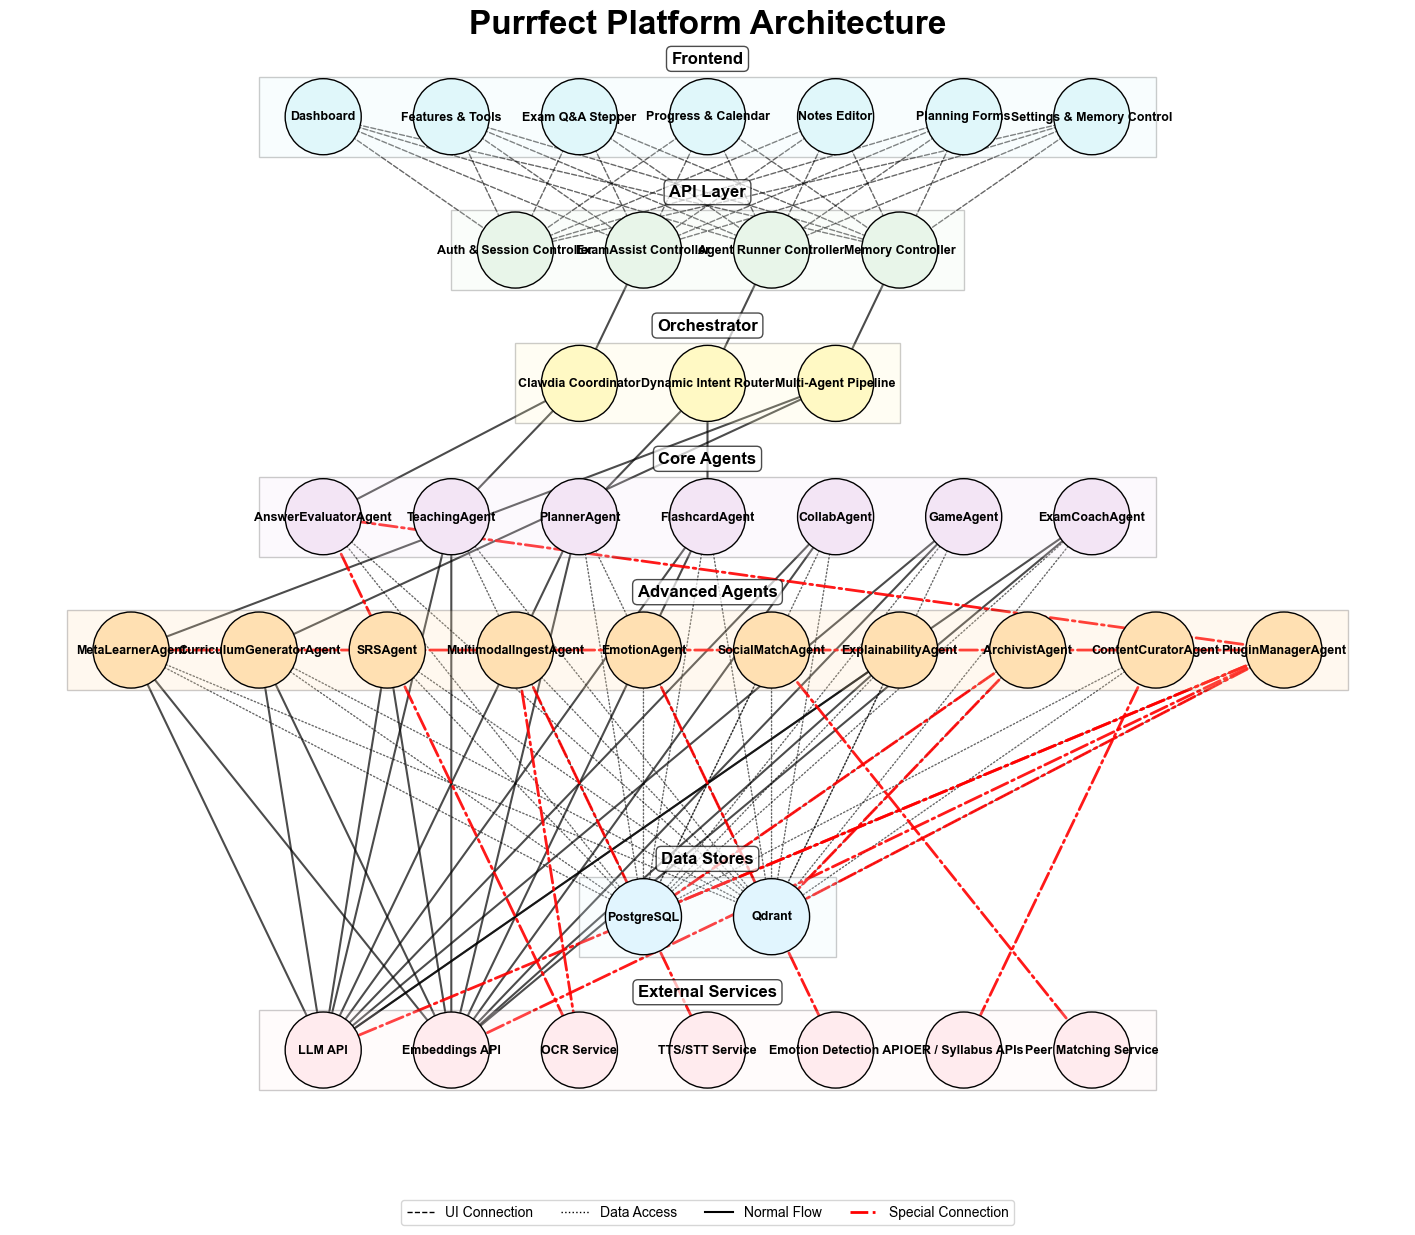

In [5]:
# Set up the figure with a large size for better readability
plt.figure(figsize=(18, 14))

# Create a custom style for the graph
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']

# Draw the nodes with custom colors based on their categories
node_color_map = [colors[node_categories[node]] for node in G.nodes()]
node_size = 3000  # Make nodes larger for better readability

# Draw nodes
nx.draw_networkx_nodes(G, pos, 
                      node_color=node_color_map, 
                      node_size=node_size,
                      edgecolors='black',
                      linewidths=1)

# Draw edges with different styles based on their categories
for cat, edges in edge_categories.items():
    if cat == 'ui':
        nx.draw_networkx_edges(G, pos, edgelist=edges, style='dashed', 
                              width=1.0, alpha=0.6, arrows=True, 
                              arrowsize=15, arrowstyle='->')
    elif cat == 'data':
        nx.draw_networkx_edges(G, pos, edgelist=edges, style='dotted', 
                              width=1.0, alpha=0.6, arrows=True,
                              arrowsize=15, arrowstyle='->')
    elif cat == 'normal':
        nx.draw_networkx_edges(G, pos, edgelist=edges, style='solid', 
                              width=1.5, alpha=0.7, arrows=True,
                              arrowsize=20, arrowstyle='->')
    elif cat == 'special':
        nx.draw_networkx_edges(G, pos, edgelist=edges, style='dashdot', 
                              width=2.0, alpha=0.9, arrows=True, 
                              edge_color='red', arrowsize=25, arrowstyle='->')

# Draw labels with appropriate font size
labels = nx.get_node_attributes(G, 'label')
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight='bold')

# Add background rectangles for each group
def add_group_background(ax, nodes, group_name, color):
    node_positions = [pos[node] for node in nodes]
    if not node_positions:
        return
    
    # Calculate the bounding box
    x_values = [p[0] for p in node_positions]
    y_values = [p[1] for p in node_positions]
    
    x_min, x_max = min(x_values) - 0.5, max(x_values) + 0.5
    y_min, y_max = min(y_values) - 0.3, max(y_values) + 0.3
    
    width = x_max - x_min
    height = y_max - y_min
    
    # Draw the rectangle
    rect = Rectangle((x_min, y_min), width, height, 
                    facecolor=color, alpha=0.2, 
                    edgecolor='black', linewidth=1)
    ax.add_patch(rect)
    
    # Add the group label
    plt.text(x_min + width/2, y_max + 0.1, group_name,
            horizontalalignment='center', fontsize=12, 
            fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3'))

# Get the current axis
ax = plt.gca()

# Add background rectangles for each group
add_group_background(ax, [n for n, _ in frontend_nodes], 'Frontend', colors['frontend'])
add_group_background(ax, [n for n, _ in api_nodes], 'API Layer', colors['api'])
add_group_background(ax, [n for n, _ in orchestrator_nodes], 'Orchestrator', colors['orchestrator'])
add_group_background(ax, [n for n, _ in core_agents_nodes], 'Core Agents', colors['core_agents'])
add_group_background(ax, [n for n, _ in advanced_agents_nodes], 'Advanced Agents', colors['advanced_agents'])
add_group_background(ax, [n for n, _ in data_store_nodes], 'Data Stores', colors['data_stores'])
add_group_background(ax, [n for n, _ in external_services_nodes], 'External Services', colors['external_services'])

# Add a title to the graph
plt.title('Purrfect Platform Architecture', fontsize=24, fontweight='bold', pad=20)

# Create a legend for the edge types
legend_elements = [
    plt.Line2D([0], [0], color='black', lw=1, linestyle='dashed', label='UI Connection'),
    plt.Line2D([0], [0], color='black', lw=1, linestyle='dotted', label='Data Access'),
    plt.Line2D([0], [0], color='black', lw=1.5, linestyle='-', label='Normal Flow'),
    plt.Line2D([0], [0], color='red', lw=2, linestyle='dashdot', label='Special Connection')
]

plt.legend(handles=legend_elements, loc='upper center', 
          bbox_to_anchor=(0.5, -0.05), ncol=4, fontsize=10)

# Remove the axis
plt.axis('off')

## 6. Display the Final Architecture

In [6]:
# Show the diagram
plt.tight_layout()

# Save the diagram as PNG
plt.savefig('purrfect_architecture.png', dpi=300, bbox_inches='tight')

# Display the diagram
plt.show()

print("Architecture diagram has been created and saved as 'purrfect_architecture.png'.")

<Figure size 640x480 with 0 Axes>

Architecture diagram has been created and saved as 'purrfect_architecture.png'.


## 7. Export the Diagram

In [7]:
# Save the diagram in different formats
try:
    # SVG format for scalable vector graphics
    plt.figure(figsize=(18, 14))
    
    # Recreate the plot (simplified version without the details)
    nx.draw(G, pos, with_labels=False, 
            node_color=node_color_map, 
            node_size=node_size,
            edgecolors='black',
            linewidths=1)
    
    # Add title
    plt.title('Purrfect Platform Architecture', fontsize=24, fontweight='bold', pad=20)
    
    # Remove the axis
    plt.axis('off')
    
    # Save as SVG
    plt.savefig('purrfect_architecture.svg', format='svg', bbox_inches='tight')
    print(f"SVG image saved as: purrfect_architecture.svg")
    
    # Close this figure to prevent display
    plt.close()
    
except Exception as e:
    print(f"SVG export failed: {e}")

print("\nYou can find these files in the current directory.")
print("The PNG version is recommended for inclusion in documentation.")

SVG image saved as: purrfect_architecture.svg

You can find these files in the current directory.
The PNG version is recommended for inclusion in documentation.


## Conclusion

This notebook has created a clear and comprehensive visualization of the Purrfect platform architecture. The diagram shows the relationships between:

- **Frontend components**: User interfaces and interaction points
- **API Layer**: Controllers that handle requests and manage sessions
- **Orchestrator**: Components that coordinate system actions
- **Core & Advanced Agents**: Specialized AI agents that perform specific functions
- **Data Stores**: Databases for persistent storage (PostgreSQL and Qdrant)
- **External Services**: Third-party APIs and services that extend functionality

The color coding and connection styles make it easy to understand the flow of data and control throughout the system.

## Documentation File

A comprehensive documentation file has been created to accompany this architecture diagram. The file `architecture_documentation.md` contains:

1. Detailed descriptions of each component
2. Explanation of all relationships between components
3. Component tables with descriptions
4. Integration patterns used in the architecture

You can use this documentation alongside the diagram to provide a complete understanding of the Purrfect Platform architecture.